<hr>
<div>
<h2>Initialize Monitoring Environment</h2>
<p>Initializes the shared imports and data access used throughout section 06. The nightly job is <code>retention.run_nightly</code>; it and this section both use <code>retention.pipeline</code> (sections 01–04 as functions) and <code>retention.monitoring</code> (drift and calibration checks).</p>
</div>

In [1]:
# Standard Library
import json
import os
import shutil
import subprocess
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, 'src')
from retention import data, monitoring as M, pipeline as PL

warnings.filterwarnings('ignore')
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

In [2]:
# Plotting Theme and Color Palette
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
TEAL = '#1baf7a'
YELLOW = '#eda100'

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

In [3]:
# Output Helpers & Constants
OUTPUTS = Path('outputs')
NIGHTLY = OUTPUTS / 'nightly'
SEED = 20260921
N_MONTHS = 24
LAST_MONTH = 30
PYTHON = sys.executable


def run(*args):
    """Runs a command from this folder, the way a scheduler would, and returns its output."""
    result = subprocess.run(list(args), capture_output = True, text = True, env = {**os.environ, 'PYTHONPATH': 'src'})
    return result.returncode, result.stdout, result.stderr

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>06 · Automation and Monitoring</h1>
<p><strong>Purpose:</strong> Turns sections 01–05 into a job that runs every night without a notebook, and checks what a nightly job has to check: that its code still does what it should, that the customers it scores still look like the ones its model learned from, and that its offers really keep customers.</p>
<p><strong>Architecture:</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Piece</th><th style="text-align: left;">What it does</th><th style="text-align: left;">Where</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">Nightly job</td><td style="text-align: left; vertical-align: top;">Checks drift and calibration, retrains if needed, plans the night, drafts messages, pauses for approval; a second call finishes the night from the reviewer's decisions</td><td style="text-align: left; vertical-align: top;"><code>retention.run_nightly</code></td></tr>
<tr><td style="text-align: left; vertical-align: top;">Regression tests</td><td style="text-align: left; vertical-align: top;">16 offline tests of the policy rules, the optimizer, and the agent graph, with stub language models</td><td style="text-align: left; vertical-align: top;"><code>tests/</code>, pytest</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Drift</td><td style="text-align: left; vertical-align: top;">Population stability index on the churn model's inputs: each month against last month, which triggers retraining, and against the training window, for context</td><td style="text-align: left; vertical-align: top;"><code>retention.monitoring</code></td></tr>
<tr><td style="text-align: left; vertical-align: top;">Calibration and retraining</td><td style="text-align: left; vertical-align: top;">Predicted against actual churn once a month is known; retrain on a sudden shift or a gap over 20%</td><td style="text-align: left; vertical-align: top;"><code>retention.monitoring</code></td></tr>
<tr><td style="text-align: left; vertical-align: top;">Holdout</td><td style="text-align: left; vertical-align: top;">The plan's real effect, from the 10% of chosen customers held back each night</td><td style="text-align: left; vertical-align: top;">This section</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Schedule</td><td style="text-align: left; vertical-align: top;">A launchd job at 2:00 a.m., provided but not installed</td><td style="text-align: left; vertical-align: top;"><code>ops/</code></td></tr>
</tbody>
</table>
<p><strong>New Months.</strong> Months 25–30 are withheld from the model-facing data. Here they arrive one at a time, as a live carrier's data would, through <code>pipeline.observed_panel()</code>. From month 27 a competitor promotion runs in every region: the drift the monitoring should catch.</p>
</div>

<hr>
<div>
<h2>1 · The Nightly Job</h2>
<p><strong>Purpose:</strong> Runs tonight's job from the command line, exactly as the scheduler would, then finishes it with a reviewer's decisions.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Two Calls.</strong> <code>python -m retention.run_nightly</code> plans the night and runs the agent until it pauses for approval, writing <code>review.json</code>. After review, <code>--resume decisions.json</code> finishes the run from its checkpoint.</li>
<li style="margin-bottom: 0.7em;"><strong>Models.</strong> Saved between nights in <code>outputs/models/</code>. The first night trains them; later nights reuse them unless monitoring says otherwise (sections 3–4).</li>
<li style="margin-bottom: 0.7em;"><strong>Agent Batch.</strong> The top 40 customers by expected net value, to keep the demonstration's API use small; a production run would draft for all of them.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The job runs without a notebook.</strong> The first night trains its models, keeps the discount and the device credit (the offers the test proved), plans 598 contacts and 68 held-out customers within &#36;35,880 of exposure, and drafts for the top 40: 38 offers, all passing on the first draft, and 2 routed to care. Under a minute end to end once the language-model responses are cached.</li>
<li style="margin-bottom: 0.7em;"><strong>Approval finishes it.</strong> Resumed from the reviewer's decisions file, the run sent 37 messages and held back the one rejected.</li>
</ol>
</div>

In [4]:
# Run Tonight's Job
shutil.rmtree(OUTPUTS / 'models', ignore_errors = True)
shutil.rmtree(NIGHTLY, ignore_errors = True)
code, stdout, stderr = run(PYTHON, '-m', 'retention.run_nightly', '--month', str(N_MONTHS), '--batch', '40')
print(f'exit code {code}')
night = json.loads((NIGHTLY / f'month-{N_MONTHS}' / 'run_log.json').read_text())
display(pd.Series({'retrained because': ', '.join(night['retrained']), 'offers used': ', '.join(night['gated_offers']),
                   **{f'plan: {k}': v for k, v in night['plan'].items()}, **{f'agent: {k}': v for k, v in night['agent'].items()},
                   'seconds': night['seconds']}).to_frame(f'month {N_MONTHS}'))

exit code 0


,month 24
retrained because,no model yet
offers used,"discount, device"
plan: customers,598
plan: held_out,68
plan: exposure,35880.0
plan: expected_cost,17435.03
plan: model_customers_kept,23.2
plan: by_offer,{'discount': 598}
agent: drafts,40
agent: offers_drafted,38


In [5]:
# Approve and Finish Tonight's Job
review = json.loads((NIGHTLY / f'month-{N_MONTHS}' / 'review.json').read_text())
offers = [d for d in review['drafts'] if d['action'] == 'send_offer']
decisions = {'approve': [d['account_id'] for d in offers if d['passed']][1:], 'reject': [offers[0]['account_id']]}
decisions_path = NIGHTLY / f'month-{N_MONTHS}' / 'decisions.json'
decisions_path.write_text(json.dumps(decisions))
code, stdout, stderr = run(PYTHON, '-m', 'retention.run_nightly', '--month', str(N_MONTHS), '--resume', str(decisions_path))
report = json.loads((NIGHTLY / f'month-{N_MONTHS}' / 'report.json').read_text())
print(f'exit code {code} · waiting at {review["waiting_at"]} before approval · {report["sent"]} messages sent, {report["rejected"]} rejected')

exit code 0 · waiting at ['human_approval'] before approval · 37 messages sent, 1 rejected


<hr>
<div>
<h2>2 · Regression Tests</h2>
<p><strong>Purpose:</strong> Runs the test suite a scheduled job needs before every change ships: fast, offline, and with no language-model calls, so it can run on every commit.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Policy.</strong> A compliant message passes; each of six planted violations is caught; each eligibility rule holds.</li>
<li style="margin-bottom: 0.7em;"><strong>Optimizer.</strong> One offer per customer, never over budget, the greedy rule within 10% of the exact solution, and held-out customers never contacted.</li>
<li style="margin-bottom: 0.7em;"><strong>Agent Graph.</strong> With stub models: an open ticket routes to care with no draft; the opt-out line is appended; a failing draft is revised, and revision stops after two; a paused run resumes from a fresh graph, and a rule-breaking edit is held back at dispatch.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>16 tests pass in about a second.</strong> No API calls and no data files beyond the synthetic tables, so they can run on every commit and before every scheduled night.</li>
</ol>
</div>

In [6]:
# Run the Tests
code, stdout, stderr = run(PYTHON, '-m', 'pytest', 'tests', '-v', '--no-header', '-p', 'no:warnings')
print('\n'.join(line for line in stdout.splitlines() if 'PASSED' in line or 'FAILED' in line or 'passed' in line or 'failed' in line))

tests/test_agent.py::test_routing_happens_in_code_without_a_draft PASSED [  6%]
tests/test_agent.py::test_opt_out_is_appended_and_first_draft_passes PASSED [ 12%]
tests/test_agent.py::test_failed_draft_is_revised PASSED                 [ 18%]
tests/test_agent.py::test_revisions_stop_after_two PASSED                [ 25%]
tests/test_agent.py::test_resume_from_a_fresh_graph_and_block_a_bad_edit PASSED [ 31%]
tests/test_optimizer.py::test_greedy_respects_budget_and_one_offer PASSED [ 37%]
tests/test_optimizer.py::test_greedy_close_to_exact PASSED               [ 43%]
tests/test_optimizer.py::test_holdout_is_never_contacted PASSED          [ 50%]
tests/test_policy.py::test_compliant_message_passes PASSED               [ 56%]
tests/test_policy.py::test_planted_violation_is_caught[Hi there! We value you. We value you. We value you. We value you. We value you. We value you. We value you. We value you. We value you. We value you. We value you. We value you. We value you. We value you. We value

<hr>
<div>
<h2>3 · Drift</h2>
<p><strong>Purpose:</strong> Checks each new month's accounts against the months the churn model learned from, input by input, to catch the population changing under the model before its predictions go wrong.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Population Stability Index.</strong> For each input, the share of accounts in each of the training window's deciles this month against the training window: Σ (actual − expected) × ln(actual / expected). Under 0.1 is stable, 0.1–0.25 worth watching, over 0.25 an alert.</li>
<li style="margin-bottom: 0.7em;"><strong>Two Baselines.</strong> Against the training window, months 12–23, the question is whether the model has seen accounts like these; against last month, whether something just changed. The first version of the monitor triggered retraining on the training window; the table shows why it no longer does.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Against the training window, the alarm never stops.</strong> Bill changes (PSI 0.53) and competitor promotions (0.78) are already in alert at month 24, before anything changed: the training window contained the month-12 price increase and the months 16–18 surge, so every ordinary month differs from it. The first version of the monitor retrained every month on these false alarms.</li>
<li style="margin-bottom: 0.7em;"><strong>Month over month, only the real change shows.</strong> Every input stays below 0.01 except competitor promotions, which jumps to 6.6 in month 27, when the promotion starts everywhere.</li>
<li style="margin-bottom: 0.7em;"><strong>One slow drift to watch.</strong> Tenure against the training window climbs to 0.15 by month 30: no new customers join in the replayed months, so the base ages. A live base would have new customers; here it's a limit of the replay.</li>
</ol>
</div>

In [7]:
# Measure Drift by Month
rows = PL.account_months(LAST_MONTH)
training = rows[rows['month'].between(12, 23)]
against_training = pd.DataFrame({m: M.drift_report(training, rows[rows['month'] == m])['psi'] for m in range(N_MONTHS, LAST_MONTH + 1)})
drift = pd.DataFrame({m: M.drift_report(rows[rows['month'] == m - 1], rows[rows['month'] == m])['psi'] for m in range(N_MONTHS, LAST_MONTH + 1)})
for table, caption in [(against_training, 'against the training window, months 12–23'), (drift, 'against the month before')]:
    display(table.style.format('{:.2f}').background_gradient(cmap = 'Oranges', vmin = 0, vmax = 0.5, axis = None)
            .set_caption(f'Population stability index by month, {caption}'))

,24,25,26,27,28,29,30
bill,0.00,0.00,0.00,0.00,0.00,0.00,0.00
bill_change_max_3m,0.54,0.53,0.53,0.53,0.53,0.53,0.53
care_contacts_3m,0.00,0.00,0.00,0.00,0.00,0.00,0.00
competitor_promo_max_3m,0.78,0.78,0.78,8.38,8.38,8.38,8.38
device_age,0.02,0.03,0.04,0.04,0.04,0.05,0.06
dropped_call_rate_3m,0.00,0.00,0.00,0.00,0.00,0.00,0.00
months_to_payoff,0.00,0.00,0.01,0.01,0.02,0.02,0.03
tenure,0.03,0.04,0.05,0.07,0.08,0.11,0.15
throttle_days_3m,0.00,0.00,0.00,0.00,0.00,0.00,0.00


,24,25,26,27,28,29,30
bill,0.00,0.00,0.00,0.00,0.00,0.00,0.00
bill_change_max_3m,0.00,0.00,0.00,0.00,0.00,0.00,0.00
care_contacts_3m,0.00,0.00,0.00,0.00,0.00,0.00,0.00
competitor_promo_max_3m,0.00,0.00,0.00,6.58,0.00,0.00,0.00
device_age,0.00,0.00,0.01,0.00,0.00,0.00,0.00
dropped_call_rate_3m,0.00,0.00,0.00,0.00,0.00,0.00,0.00
months_to_payoff,0.00,0.00,0.00,0.00,0.00,0.00,0.00
tenure,0.00,0.00,0.00,0.00,0.00,0.00,0.00
throttle_days_3m,0.00,0.00,0.00,0.00,0.00,0.00,0.00


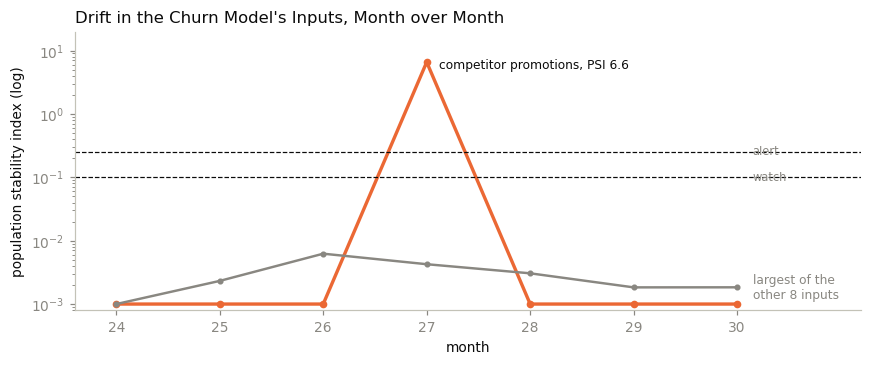

In [8]:
# Plot: Drift in the Churn Model's Inputs
FLOOR = 0.001
promo = drift.loc['competitor_promo_max_3m'].clip(lower = FLOOR)
others = drift.drop('competitor_promo_max_3m').max().clip(lower = FLOOR)
fig, ax = plt.subplots(figsize = (8, 3.4))
ax.plot(drift.columns, promo, color = ACCENT2, linewidth = 2.2, marker = 'o', markersize = 4)
ax.plot(drift.columns, others, color = MUTED, linewidth = 1.6, marker = 'o', markersize = 3)
ax.annotate(f'competitor promotions, PSI {promo.max():.1f}', xy = (promo.idxmax(), promo.max()), xytext = (8, -2),
            textcoords = 'offset points', fontsize = 8, color = INK, va = 'center')
ax.text(drift.columns[-1] + 0.15, others.iloc[-1], 'largest of the\nother 8 inputs', va = 'center', fontsize = 8, color = MUTED)
for level, label in [(M.PSI_WATCH, 'watch'), (M.PSI_ALERT, 'alert')]:
    ax.axhline(level, color = INK, linewidth = 0.8, linestyle = '--')
    ax.text(drift.columns[-1] + 0.15, level, label, va = 'center', fontsize = 7.5, color = MUTED)
ax.set_yscale('log')
ax.set_ylim(FLOOR * 0.8, promo.max() * 3)
ax.set_xlim(N_MONTHS - 0.4, LAST_MONTH + 1.2)
ax.set_xticks(range(N_MONTHS, LAST_MONTH + 1))
ax.set_xlabel('month')
ax.set_ylabel('population stability index (log)')
ax.set_title('Drift in the Churn Model\'s Inputs, Month over Month', loc = 'left')
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>4 · Calibration and Retraining</h2>
<p><strong>Purpose:</strong> Once each month's outcome is known, compares predicted with actual churn, and shows what retraining on a monitoring signal buys over keeping tonight's model.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Two Policies.</strong> Keep tonight's model for every month, or retrain the monitored way: at the start of each month, retrain on the latest 12 labeled months if any input shifted sharply since last month (PSI over 0.25) or last month's predictions were off by more than 20%.</li>
<li style="margin-bottom: 0.7em;"><strong>Measure.</strong> Each month's mean predicted chance of leaving the next month against the share who did, among accounts still active. Months 24–29 can be scored; month 30's outcome is beyond the data.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>One retrain, when it mattered.</strong> The monitored policy retrained once, at month 27, on both signals: the promotion's input shift and a 33% miss the month before.</li>
<li style="margin-bottom: 0.7em;"><strong>Neither model could see month 27 coming.</strong> Scored at month 26, both predicted 1.27%, and 1.89% left: the promotion started in month 27, after month 26's inputs were recorded. No monitor prevents that miss; it limits it to one month.</li>
<li style="margin-bottom: 0.7em;"><strong>Retraining added little, and that's informative.</strong> From month 27 both models are within 5% of actual churn. Tonight's model was trained through the months 16–18 surge, so it already knew what a competitor promotion does; the new inputs carried the change. Monitoring's value here was the alert and the certainty, not a better model.</li>
</ol>
</div>

In [9]:
# Replay Months 24–29 with Both Policies
stale = PL.train_churn_model(rows, N_MONTHS)
monitored, retrained_at, gap_last = stale, [], None
records = []
for month in range(N_MONTHS, LAST_MONTH):
    if month > N_MONTHS:
        check = M.drift_report(rows[rows['month'] == month - 1], rows[rows['month'] == month])
        retrain, reasons = M.should_retrain(check, gap_last)
        if retrain:
            monitored = PL.train_churn_model(rows, month)
            retrained_at.append((month, reasons))
    scored = rows[(rows['month'] == month) & rows['left_next_month'].notna()]
    actual = scored['left_next_month'].mean()
    stale_p = stale.probabilities(scored)['p_churn_30'].mean()
    monitored_p = monitored.probabilities(scored)['p_churn_30'].mean()
    gap_last = monitored_p / actual - 1
    records.append({'month': month, 'actual': actual, "tonight's model": stale_p, 'monitored': monitored_p,
                    "tonight's model gap": stale_p / actual - 1, 'monitored gap': gap_last})
replay = pd.DataFrame(records).set_index('month')
for month, reasons in retrained_at:
    print(f'month {month}: retrained because {"; ".join(reasons)}')
display(replay.style.format({'actual': '{:.2%}', "tonight's model": '{:.2%}', 'monitored': '{:.2%}',
                             "tonight's model gap": '{:+.0%}', 'monitored gap': '{:+.0%}'}))

month 27: retrained because competitor_promo_max_3m: PSI 6.58; calibration off by -33%


,actual,tonight's model,monitored,tonight's model gap,monitored gap
month,,,,,
24,1.21%,1.30%,1.30%,+8%,+8%
25,1.17%,1.29%,1.29%,+11%,+11%
26,1.89%,1.27%,1.27%,-33%,-33%
27,1.86%,1.91%,1.94%,+3%,+4%
28,1.89%,1.90%,1.93%,+1%,+2%
29,1.82%,1.89%,1.91%,+4%,+5%


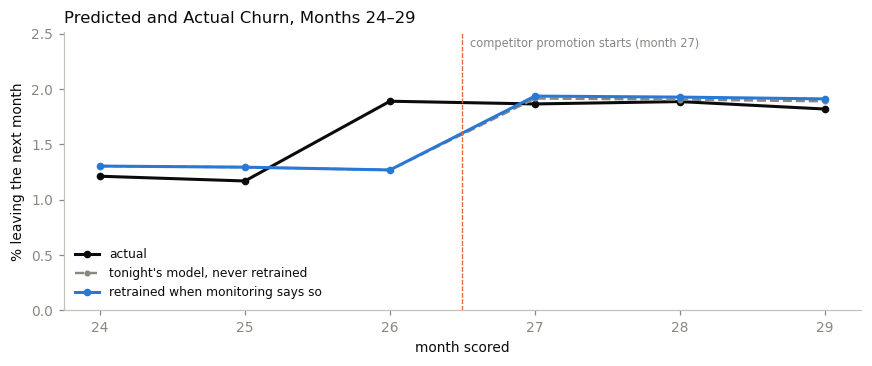

In [10]:
# Plot: Predicted and Actual Churn by Month
fig, ax = plt.subplots(figsize = (8, 3.4))
ax.plot(replay.index, replay['actual'] * 100, color = INK, linewidth = 2, marker = 'o', markersize = 4, label = 'actual')
ax.plot(replay.index, replay["tonight's model"] * 100, color = MUTED, linewidth = 1.6, linestyle = '--', marker = 'o', markersize = 3, label = "tonight's model, never retrained")
ax.plot(replay.index, replay['monitored'] * 100, color = ACCENT, linewidth = 2, marker = 'o', markersize = 4, label = 'retrained when monitoring says so')
for month, _ in retrained_at:
    ax.axvline(month - 0.5, color = ACCENT, linewidth = 0.8, linestyle = ':')
ax.set_ylim(0, max(replay[['actual', "tonight's model", 'monitored']].max()) * 100 * 1.3)
ax.axvline(26.5, color = ACCENT2, linewidth = 0.8, linestyle = '--')
ax.text(26.55, ax.get_ylim()[1] * 0.98, 'competitor promotion starts (month 27)', fontsize = 7.5, color = MUTED, va = 'top')
ax.set_xlabel('month scored')
ax.set_ylabel('% leaving the next month')
ax.set_title('Predicted and Actual Churn, Months 24–29', loc = 'left')
ax.legend(frameon = False, fontsize = 8, loc = 'lower left')
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>5 · Measuring the Plan</h2>
<p><strong>Purpose:</strong> Measures the plan's real effect the only unbiased way available: by comparing the chosen customers who were contacted with the chosen customers held back.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Outcomes.</strong> The study's future months were generated without tonight's offers, so the 90 days after tonight are simulated from the answer key: each contacted customer leaves with their true probability under the offer, each held-out customer with their true probability without it.</li>
<li style="margin-bottom: 0.7em;"><strong>Estimate.</strong> Held-out churn minus contacted churn, with a 95% interval; compared with what the plan forecast and with the truth.</li>
<li style="margin-bottom: 0.7em;"><strong>Nights Needed.</strong> One night's holdout is small, so the precision of the estimate after pooling n nights of the same size, and the number of nights needed to detect the true effect with 80% power.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>One night can't measure the plan.</strong> 598 contacted customers left at 2.2% and 68 held-out customers at 4.4%: a measured effect of 2.2 points, with a 95% interval from −2.8 to +7.3. The true effect is 3.0 points.</li>
<li style="margin-bottom: 0.7em;"><strong>The plan's own forecast is high.</strong> It expected 3.9 points, 30% above the truth: section 04's winner's curse, still there after the guardrails, and exactly why the holdout exists.</li>
<li style="margin-bottom: 0.7em;"><strong>Eight nights settle it.</strong> Pooled across 8 nights of this size, the holdout detects the true effect with 80% power; after 30 nights the interval is about ±1 point, precise enough to recalibrate the plan's forecasts.</li>
</ol>
</div>

In [11]:
# Measure the Plan against Its Holdout
plan = pd.read_parquet(NIGHTLY / f'month-{N_MONTHS}' / 'plan.parquet')
truth = data.load_answer_key('truth_potential_outcomes').set_index('account_id').loc[plan['account_id']]
p_if_contacted = np.array([truth.iloc[i][f'p_churn_90_{o}'] for i, o in enumerate(plan['offer'])])
p_if_held = truth['p_churn_90_control'].to_numpy()
rng = np.random.default_rng(SEED)
left = np.where(plan['holdout'], rng.random(len(plan)) < p_if_held, rng.random(len(plan)) < p_if_contacted)

held, contacted = left[plan['holdout'].to_numpy()], left[~plan['holdout'].to_numpy()]
estimate = held.mean() - contacted.mean()
se = np.sqrt(held.mean() * (1 - held.mean()) / len(held) + contacted.mean() * (1 - contacted.mean()) / len(contacted))
true_effect = (p_if_held - p_if_contacted)[~plan['holdout'].to_numpy()].mean()
forecast = plan.loc[~plan['holdout'], 'uplift'].mean()

display(pd.DataFrame({
    'contacted': [len(contacted)], 'held out': [len(held)],
    'churn, contacted': [contacted.mean()], 'churn, held out': [held.mean()],
    'measured effect, points': [estimate * 100], '95% interval, points': [f'{(estimate - 1.96 * se) * 100:+.1f} to {(estimate + 1.96 * se) * 100:+.1f}'],
    'true effect, points': [true_effect * 100], 'plan\'s forecast, points': [forecast * 100],
}, index = [f'month {N_MONTHS}']).style.format({'churn, contacted': '{:.1%}', 'churn, held out': '{:.1%}', 'measured effect, points': '{:+.1f}',
                                                 'true effect, points': '{:+.1f}', 'plan\'s forecast, points': '{:+.1f}'}))

base = p_if_held.mean()
per_night_variance = base * (1 - base) / len(held) + base * (1 - base) / len(contacted)
nights = pd.DataFrame({'nights pooled': [1, 5, 10, 20, 30, 60]})
nights['95% interval, ± points'] = 1.96 * np.sqrt(per_night_variance / nights['nights pooled']) * 100
needed = int(np.ceil(per_night_variance * (1.96 + 0.84) ** 2 / true_effect ** 2))
print(f'nights of this size needed to detect the true {true_effect * 100:.1f}-point effect with 80% power: {needed}')
display(nights.style.format({'95% interval, ± points': '{:.1f}'}).hide(axis = 'index'))

,contacted,held out,"churn, contacted","churn, held out","measured effect, points","95% interval, points","true effect, points","plan's forecast, points"
month 24,598,68,2.2%,4.4%,+2.2,-2.8 to +7.3,+3.0,+3.9


nights of this size needed to detect the true 3.0-point effect with 80% power: 8


nights pooled,"95% interval, ± points"
1,5.6
5,2.5
10,1.8
20,1.2
30,1.0
60,0.7


<hr>
<div>
<h2>6 · Schedule</h2>
<p><strong>Purpose:</strong> Shows how the job would be scheduled. The study provides the files but doesn't install them: a scheduled job changes the machine it runs on, which is its owner's decision.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>launchd (macOS).</strong> <code>ops/com.datafxlab.retention-nightly.plist</code> runs the job at 2:00 a.m. from this folder; installing it is two commands, written at the top of the file.</li>
<li style="margin-bottom: 0.7em;"><strong>cron (Linux).</strong> The same job as one line: <code>0 2 * * * cd /path/to/customer-retention-agent &amp;&amp; PYTHONPATH=src python -m retention.run_nightly</code></li>
<li style="margin-bottom: 0.7em;"><strong>Approval.</strong> The scheduled run stops at human approval by design; the reviewer's tool writes the decisions file and calls <code>--resume</code>.</li>
</ol>
</div>

In [12]:
# Validate the Schedule File
code, stdout, stderr = run('/usr/bin/plutil', '-lint', 'ops/com.datafxlab.retention-nightly.plist')
print(stdout.strip())

ops/com.datafxlab.retention-nightly.plist: OK


<hr>
<div>
<h2>Section 06 Summary</h2>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The study runs as a job.</strong> <code>python -m retention.run_nightly</code> plans a night, drafts its messages, and stops for approval; <code>--resume</code> finishes it. A launchd file schedules it for 2:00 a.m., provided but not installed.</li>
<li style="margin-bottom: 0.7em;"><strong>It's tested.</strong> 16 offline tests cover the policy's rules, the optimizer's guarantees, and the agent's routing, revision, pause, resume, and last check before sending.</li>
<li style="margin-bottom: 0.7em;"><strong>Monitor against last month, not the training window.</strong> Against a training window that held a price increase and a promotion, drift alarms fire every month. Month over month, the monitor caught the one real change, the month-27 promotion, and retrained once.</li>
<li style="margin-bottom: 0.7em;"><strong>Measure with the holdout.</strong> The plan's forecast stays about 30% optimistic; eight nights of held-out customers measure its real effect, and a month of them measures it to about a point.</li>
</ol>
</div>